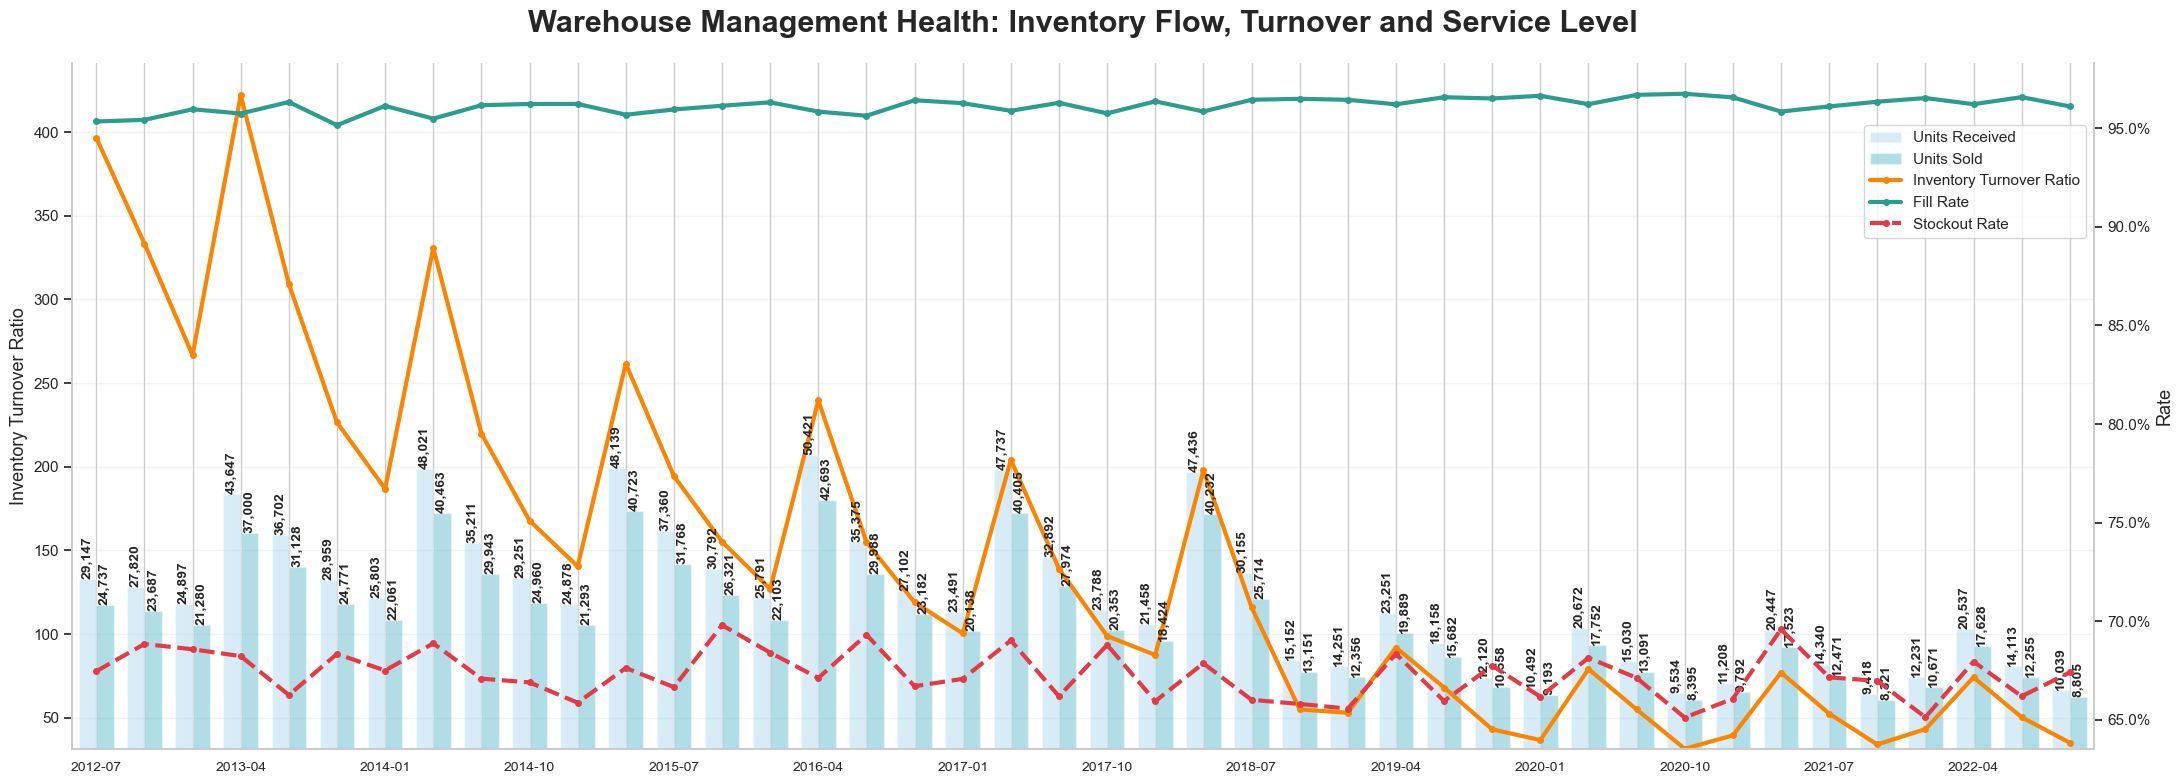

,quarter,units_received,units_sold,avg_stock_on_hand,inventory_turnover_ratio,fill_rate,stockout_rate
0,2012-07-01,29147,24737,62.371981,396.604368,0.953382,0.674718
1,2012-10-01,27820,23687,71.049345,333.388015,0.954202,0.688512
2,2013-01-01,24897,21280,79.795609,266.681340,0.959575,0.685844
3,2013-04-01,43647,37000,87.669712,422.038572,0.957415,0.682361
4,2013-07-01,36702,31128,100.661962,309.232995,0.963255,0.662668
5,2013-10-01,28959,24771,109.369056,226.490023,0.951502,0.683463
6,2014-01-01,25803,22061,118.074928,186.838988,0.961288,0.675072
7,2014-04-01,48021,40463,122.306579,330.832571,0.954823,0.688816
8,2014-07-01,35211,29943,136.195270,219.853450,0.961623,0.670946
9,2014-10-01,29251,24960,148.724089,167.827554,0.962259,0.669049


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

inventory = pd.read_csv("../data/inventory.csv", parse_dates=["snapshot_date"])

inventory["quarter"] = inventory["snapshot_date"].dt.to_period("Q").dt.to_timestamp()

quarterly = (
    inventory
    .groupby("quarter", as_index=False)
    .agg(
        units_received=("units_received", "sum"),
        units_sold=("units_sold", "sum"),
        avg_stock_on_hand=("stock_on_hand", "mean"),
        fill_rate=("fill_rate", "mean"),
        stockout_rate=("stockout_flag", "mean")
    )
)

quarterly["inventory_turnover_ratio"] = (
    quarterly["units_sold"] / quarterly["avg_stock_on_hand"]
)

quarterly = quarterly.replace([np.inf, -np.inf], np.nan).fillna(0)

bar_base = quarterly["inventory_turnover_ratio"].min()
bar_range = quarterly["inventory_turnover_ratio"].max() - quarterly["inventory_turnover_ratio"].min()

if bar_range == 0:
    bar_range = 1

max_units = quarterly[["units_received", "units_sold"]].max().max()

quarterly["received_bar_height"] = (
    quarterly["units_received"] / max_units * bar_range * 0.45
)

quarterly["sold_bar_height"] = (
    quarterly["units_sold"] / max_units * bar_range * 0.45
)

x = np.arange(len(quarterly))
bar_width = 0.36

fig, ax_turnover = plt.subplots(figsize=(22, 8))

bars_received = ax_turnover.bar(
    x - bar_width / 2,
    quarterly["received_bar_height"],
    width=bar_width,
    bottom=bar_base,
    label="Units Received",
    alpha=0.35,
    color="#8ECAE6"
)

bars_sold = ax_turnover.bar(
    x + bar_width / 2,
    quarterly["sold_bar_height"],
    width=bar_width,
    bottom=bar_base,
    label="Units Sold",
    alpha=0.35,
    color="#219EBC"
)

for i, row in quarterly.iterrows():
    ax_turnover.text(
        x[i] - bar_width / 2,
        bar_base + row["received_bar_height"],
        f'{row["units_received"]:,.0f}',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        rotation=90
    )

    ax_turnover.text(
        x[i] + bar_width / 2,
        bar_base + row["sold_bar_height"],
        f'{row["units_sold"]:,.0f}',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        rotation=90
    )

line_turnover = ax_turnover.plot(
    x,
    quarterly["inventory_turnover_ratio"],
    linewidth=3,
    marker="o",
    markersize=4,
    color="#FB8500",
    label="Inventory Turnover Ratio"
)

ax_turnover.set_ylabel("Inventory Turnover Ratio", fontsize=13)

ax_rate = ax_turnover.twinx()

line_fill = ax_rate.plot(
    x,
    quarterly["fill_rate"],
    linewidth=3,
    marker="o",
    markersize=4,
    color="#2A9D8F",
    label="Fill Rate"
)

line_stockout = ax_rate.plot(
    x,
    quarterly["stockout_rate"],
    linewidth=3,
    marker="o",
    markersize=4,
    linestyle="--",
    color="#E63946",
    label="Stockout Rate"
)

ax_rate.set_ylabel("Rate", fontsize=13)
ax_rate.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

step = 3 if len(quarterly) > 36 else 1

ax_turnover.set_xticks(x)
ax_turnover.set_xticklabels(
    [
        q.strftime("%Y-%m") if i % step == 0 else ""
        for i, q in enumerate(quarterly["quarter"])
    ],
    rotation=0,
    ha="center",
    fontsize=10
)

ax_turnover.set_xlim(-0.5, len(x) - 0.5)

plt.title(
    "Warehouse Management Health: Inventory Flow, Turnover and Service Level",
    fontsize=22,
    fontweight="bold",
    pad=22
)

handles = [
    bars_received[0],
    bars_sold[0],
    line_turnover[0],
    line_fill[0],
    line_stockout[0]
]

labels = [
    "Units Received",
    "Units Sold",
    "Inventory Turnover Ratio",
    "Fill Rate",
    "Stockout Rate"
]

ax_turnover.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1, 0.92),  
    fontsize=11,
    frameon=True
)
ax_turnover.grid(axis="y", alpha=0.25)
ax_rate.grid(False)

sns.despine(right=False)
plt.tight_layout()
plt.show()

quarterly[
    [
        "quarter",
        "units_received",
        "units_sold",
        "avg_stock_on_hand",
        "inventory_turnover_ratio",
        "fill_rate",
        "stockout_rate"
    ]
]

In [7]:
save_path = "../data/quarterly_inventory_analysis.csv"
quarterly.to_csv(save_path, index=False)

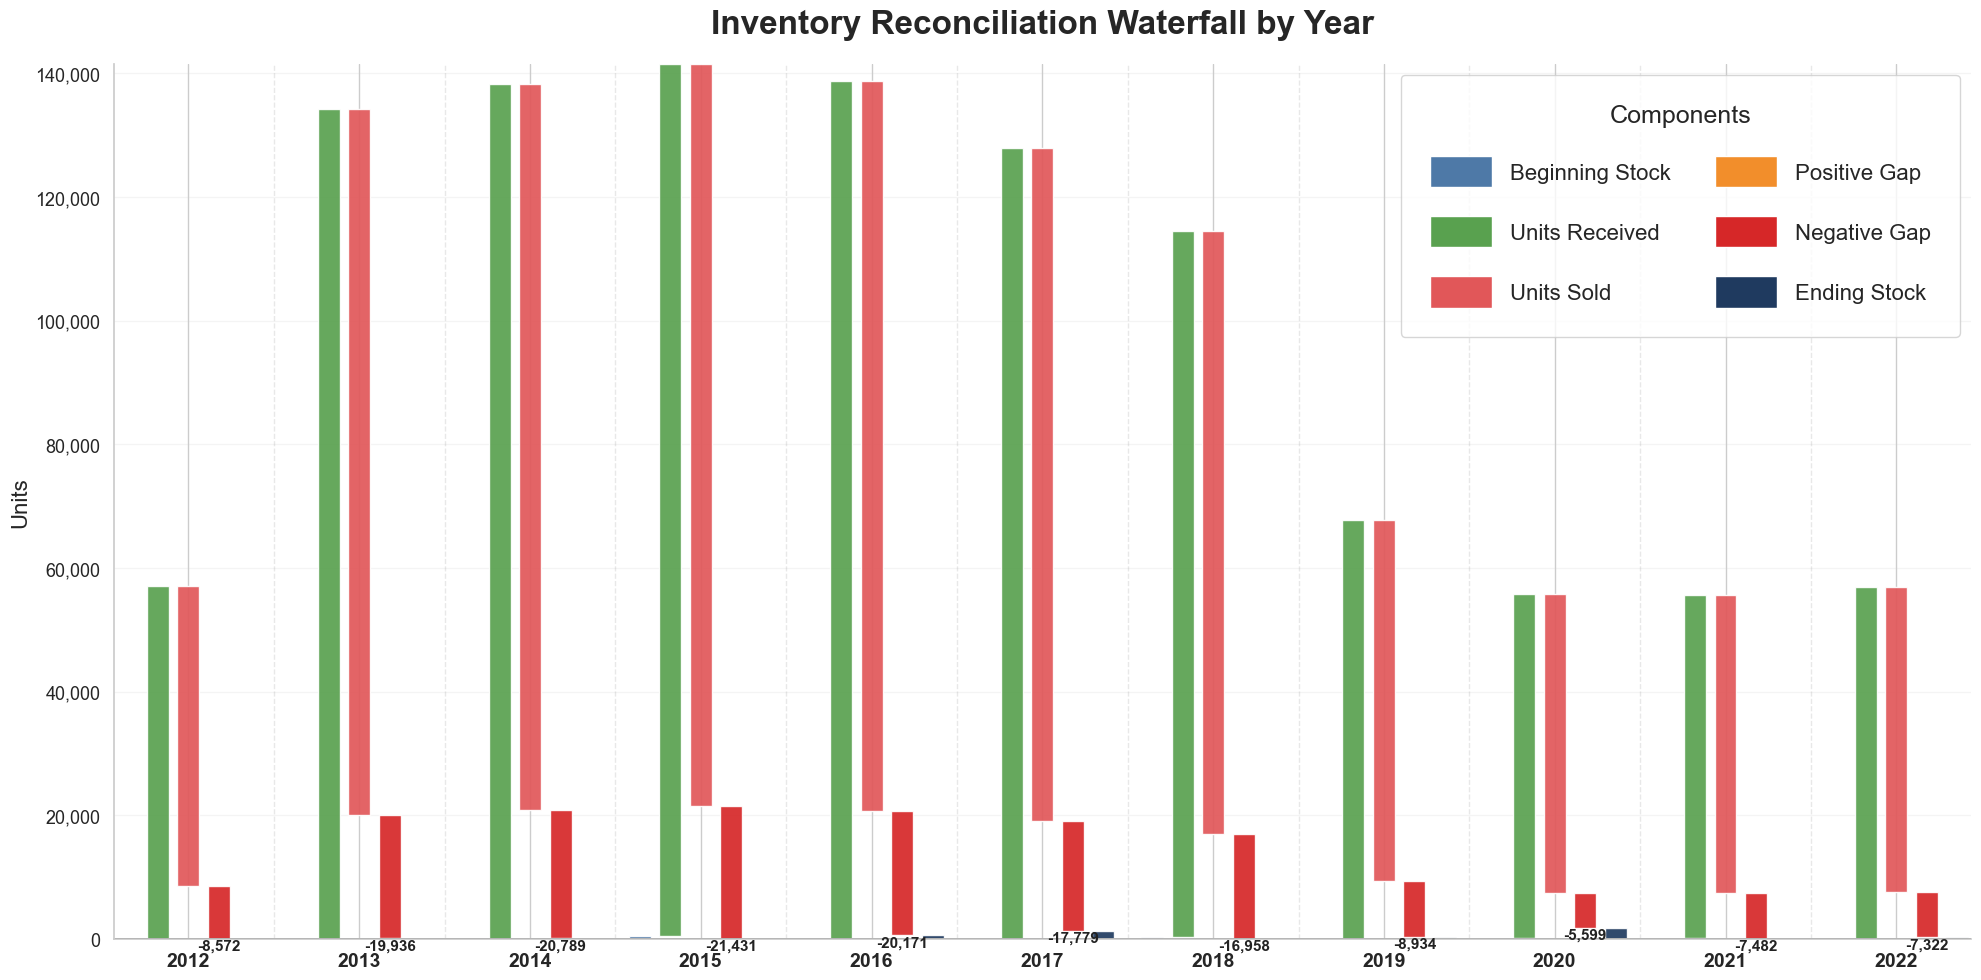

,year,beginning_stock,ending_stock,units_received,units_sold,expected_ending_stock,inventory_gap
0,2012,32,3,56967,48424,8575,-8572
1,2013,3,93,134205,114179,20029,-19936
2,2014,6,76,138286,117427,20865,-20789
3,2015,386,19,141169,120105,21450,-21431
4,2016,5,557,138689,117966,20728,-20171
5,2017,49,1308,127908,108870,19087,-17779
6,2018,287,9,114201,97521,16967,-16958
7,2019,3,364,67780,58485,9298,-8934
8,2020,85,1783,55728,48431,7382,-5599
9,2021,179,3,55413,48107,7485,-7482


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch

sns.set(style="whitegrid")

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 26,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 13,
    "legend.fontsize": 13
})

inventory = pd.read_csv("../data/inventory.csv", parse_dates=["snapshot_date"])

inventory["year"] = inventory["snapshot_date"].dt.year

yearly = (
    inventory
    .sort_values("snapshot_date")
    .groupby("year", as_index=False)
    .agg(
        beginning_stock=("stock_on_hand", "first"),
        ending_stock=("stock_on_hand", "last"),
        units_received=("units_received", "sum"),
        units_sold=("units_sold", "sum")
    )
)

yearly["expected_ending_stock"] = (
    yearly["beginning_stock"]
    + yearly["units_received"]
    - yearly["units_sold"]
)

yearly["inventory_gap"] = (
    yearly["ending_stock"] - yearly["expected_ending_stock"]
)

steps = ["Start", "Received", "Sold", "Gap", "End"]

colors = {
    "Start": "#4E79A7",
    "Received": "#59A14F",
    "Sold": "#E15759",
    "Gap_Positive": "#F28E2B",
    "Gap_Negative": "#D62728",
    "End": "#1F3A5F"
}

fig, ax = plt.subplots(figsize=(20, 10))

bar_width = 0.72
gap_between_years = 0.6

x_positions = []
bar_values = []
bar_bottoms = []
bar_colors = []
bar_steps = []
year_centers = []

current_x = 0

for _, row in yearly.iterrows():
    values = [
        row["beginning_stock"],
        row["units_received"],
        -row["units_sold"],
        row["inventory_gap"],
        row["ending_stock"]
    ]

    running = [0]
    for v in values[:-1]:
        running.append(running[-1] + v)

    bottoms = running[:-1] + [0]
    year_x = []

    for step, value, bottom in zip(steps, values, bottoms):
        x_positions.append(current_x)
        bar_values.append(value)
        bar_bottoms.append(bottom)
        bar_steps.append(step)
        year_x.append(current_x)

        if step == "Gap":
            bar_colors.append(
                colors["Gap_Negative"] if value < 0 else colors["Gap_Positive"]
            )
        else:
            bar_colors.append(colors[step])

        current_x += 1

    year_centers.append((np.mean(year_x), int(row["year"])))
    current_x += gap_between_years

bars = ax.bar(
    x_positions,
    bar_values,
    bottom=bar_bottoms,
    width=bar_width,
    color=bar_colors,
    alpha=0.92
)

for x, value, bottom, step in zip(x_positions, bar_values, bar_bottoms, bar_steps):
    if step != "Gap":
        continue

    y = bottom + value

    ax.text(
        x,
        y,
        f"{value:,.0f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=11,
        fontweight="bold",
        color="#222222"
    )

ax.set_xticks([center for center, _ in year_centers])
ax.set_xticklabels(
    [str(year) for _, year in year_centers],
    fontsize=14,
    fontweight="bold"
)

for idx in range(1, len(year_centers)):
    sep_x = (year_centers[idx - 1][0] + year_centers[idx][0]) / 2
    ax.axvline(
        sep_x,
        color="gray",
        linestyle="--",
        alpha=0.18,
        linewidth=1
    )

ax.set_xlim(min(x_positions) - 0.45, max(x_positions) + 0.45)

ax.axhline(0, color="black", linewidth=1.2)

ax.set_title(
    "Inventory Reconciliation Waterfall by Year",
    fontsize=24,
    fontweight="bold",
    pad=22
)

ax.set_ylabel("Units")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

legend_items = [
    Patch(facecolor=colors["Start"], label="Beginning Stock"),
    Patch(facecolor=colors["Received"], label="Units Received"),
    Patch(facecolor=colors["Sold"], label="Units Sold"),
    Patch(facecolor=colors["Gap_Positive"], label="Positive Gap"),
    Patch(facecolor=colors["Gap_Negative"], label="Negative Gap"),
    Patch(facecolor=colors["End"], label="Ending Stock"),
]

ax.legend(
    handles=legend_items,
    loc="upper right",
    fontsize=16,
    title="Components",
    title_fontsize=18,
    ncol=2,               
    handleheight=1.8,
    handlelength=2.8,
    labelspacing=1.3,
    borderpad=1.3,
    frameon=True
)

ax.grid(axis="y", alpha=0.2)
sns.despine()

plt.tight_layout()
plt.show()

yearly

In [9]:
csv_path = "../data/yearly_inventory_reconciliation.csv"
yearly.to_csv(csv_path, index=False)

Inventory Value             3.876299e+08
Stock Available             1.042350e+05
Turnover Ratio              4.013070e+01
Inventory to Sales Ratio    2.736833e-02
Avg Days Supply             5.726724e+03
dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_3300\9674599.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items_df = pd.read_csv('../data/order_items.csv')


In [14]:
import pandas as pd
import numpy as np

# Load data
inventory_df = pd.read_csv('../data/inventory.csv')
products_df = pd.read_csv('../data/products.csv')
order_items_df = pd.read_csv('../data/order_items.csv')

# Convert date
inventory_df['snapshot_date'] = pd.to_datetime(inventory_df['snapshot_date'])

# Merge inventory + products
df = inventory_df.merge(
    products_df[['product_id', 'cogs']],
    on='product_id',
    how='left'
)

# Inventory value
df['inventory_value'] = df['stock_on_hand'] * df['cogs']

# Snapshot tháng mới nhất
latest_date = df['snapshot_date'].max()
latest_df = df[df['snapshot_date'] == latest_date]

# Merge orders + products
order_df = order_items_df.merge(
    products_df[['product_id', 'cogs']],
    on='product_id',
    how='left'
)

# COGS sold
order_df['cogs_sold'] = order_df['quantity'] * order_df['cogs']

# KPI 1 Inventory Value
inventory_value = latest_df['inventory_value'].sum()

# KPI 2 Stock Available
stock_available = latest_df['stock_on_hand'].sum()

# KPI 3 Average Inventory toàn bộ dataset
avg_inventory = df.groupby(
    'snapshot_date'
)['inventory_value'].sum().mean()

# KPI 4 Turnover Ratio
cogs_sold = order_df['cogs_sold'].sum()

turnover = cogs_sold / avg_inventory

# KPI 5 Inventory to Sales Ratio
inventory_to_sales = inventory_value / cogs_sold

# KPI 6 Avg Days Supply
latest_df['days_of_supply'] = latest_df['days_of_supply'].clip(upper=365)

avg_days_supply = (
    latest_df['days_of_supply'] *
    latest_df['stock_on_hand']
).sum() / latest_df['stock_on_hand'].sum()

# Final KPI
kpi = {
    'Inventory Value': inventory_value,
    'Stock Available': stock_available,
    'Turnover Ratio': turnover,
    'Inventory to Sales Ratio': inventory_to_sales,
    'Avg Days Supply': avg_days_supply
}

print(pd.Series(kpi))

Inventory Value             3.876299e+08
Stock Available             1.042350e+05
Turnover Ratio              4.013070e+01
Inventory to Sales Ratio    2.736833e-02
Avg Days Supply             3.528300e+02
dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_3300\3722326962.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items_df = pd.read_csv('../data/order_items.csv')
C:\Users\Admin\AppData\Local\Temp\ipykernel_3300\3722326962.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest_df['days_of_supply'] = latest_df['days_of_supply'].clip(upper=365)
